In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
st = pd.read_csv("student-mat.csv", sep=";")

In [5]:
st.shape

(395, 33)

In [6]:
st.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [7]:
st.columns.tolist()

['school',
 'sex',
 'age',
 'address',
 'famsize',
 'Pstatus',
 'Medu',
 'Fedu',
 'Mjob',
 'Fjob',
 'reason',
 'guardian',
 'traveltime',
 'studytime',
 'failures',
 'schoolsup',
 'famsup',
 'paid',
 'activities',
 'nursery',
 'higher',
 'internet',
 'romantic',
 'famrel',
 'freetime',
 'goout',
 'Dalc',
 'Walc',
 'health',
 'absences',
 'G1',
 'G2',
 'G3']

In [8]:
st.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [9]:
st.isnull().sum().sum()

np.int64(0)

In [10]:
st["G3"].describe()

count    395.000000
mean      10.415190
std        4.581443
min        0.000000
25%        8.000000
50%       11.000000
75%       14.000000
max       20.000000
Name: G3, dtype: float64

In [11]:
st1 = st.copy()

In [12]:
st1.shape

(395, 33)

In [13]:
st1.columns.tolist()

['school',
 'sex',
 'age',
 'address',
 'famsize',
 'Pstatus',
 'Medu',
 'Fedu',
 'Mjob',
 'Fjob',
 'reason',
 'guardian',
 'traveltime',
 'studytime',
 'failures',
 'schoolsup',
 'famsup',
 'paid',
 'activities',
 'nursery',
 'higher',
 'internet',
 'romantic',
 'famrel',
 'freetime',
 'goout',
 'Dalc',
 'Walc',
 'health',
 'absences',
 'G1',
 'G2',
 'G3']

In [14]:
st1["pass"] = (st1["G3"] >= 10).astype(int)

In [15]:
st1[["G3", "pass"]].head(10)

,G3,pass
0,6,0
1,6,0
2,10,1
3,15,1
4,10,1
5,15,1
6,11,1
7,6,0
8,19,1
9,15,1


In [16]:
st1["pass"].value_counts()

pass
1    265
0    130
Name: count, dtype: int64

In [17]:
st1["pass"].value_counts(normalize=True).mul(100).round(2)

pass
1    67.09
0    32.91
Name: proportion, dtype: float64

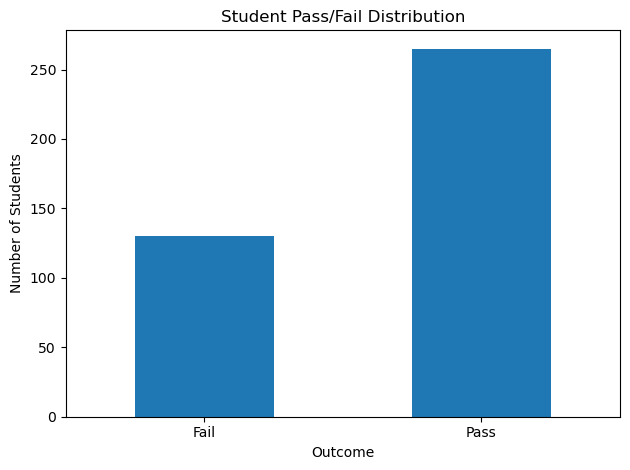

In [18]:
st1["pass"].value_counts().sort_index().plot(kind="bar")
plt.title("Student Pass/Fail Distribution")
plt.xlabel("Outcome")
plt.ylabel("Number of Students")
plt.xticks([0,1], ["Fail", "Pass"], rotation=0)
plt.tight_layout()
plt.show()

In [19]:
st1 = st1.drop(columns=["G1", "G2", "G3"])

In [20]:
st1.shape

(395, 31)

In [21]:
st1.columns.tolist()

['school',
 'sex',
 'age',
 'address',
 'famsize',
 'Pstatus',
 'Medu',
 'Fedu',
 'Mjob',
 'Fjob',
 'reason',
 'guardian',
 'traveltime',
 'studytime',
 'failures',
 'schoolsup',
 'famsup',
 'paid',
 'activities',
 'nursery',
 'higher',
 'internet',
 'romantic',
 'famrel',
 'freetime',
 'goout',
 'Dalc',
 'Walc',
 'health',
 'absences',
 'pass']

In [22]:
x = st1.drop(columns=["pass"])
y = st1["pass"]

In [23]:
x.shape

(395, 30)

In [24]:
y.shape

(395,)

In [25]:
categorical_cols = x.select_dtypes(include=["object"]).columns.tolist()
numerical_cols=x.select_dtypes(exclude=["object"]).columns.tolist()

In [26]:
print(categorical_cols)

['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']


In [27]:
print(numerical_cols)

['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences']


In [28]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=42, stratify=y)

In [29]:
len(x_train)

316

In [30]:
len(y_test)

79

In [31]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

In [32]:
preprocessor_tree = ColumnTransformer(transformers=[("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_cols), ("numerical", "passthrough", numerical_cols)])

In [33]:
preprocessor_svm = ColumnTransformer(transformers=[("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_cols), ("numerical", StandardScaler(), numerical_cols)])

In [34]:
from sklearn.tree import DecisionTreeClassifier
decision_tree = Pipeline(steps=[("preprocessor", preprocessor_tree), ("model", DecisionTreeClassifier(max_depth=5, random_state=42))])

In [35]:
decision_tree.fit(x_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('categorical', ...), ('numerical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [36]:
y_pred_tree = decision_tree.predict(x_test)

In [37]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay)

In [38]:
tree_accuracy = accuracy_score(y_test, y_pred_tree)
tree_precision = precision_score(y_test, y_pred_tree)
tree_recall = recall_score(y_test, y_pred_tree)
tree_f1 = f1_score(y_test, y_pred_tree)
print("Decision Tree Results")
print("Accuracy: ", round(tree_accuracy, 4))
print("Precision: ", round(tree_precision, 4))
print("Recall: ", round(tree_recall, 4))
print("F1-score: ", round(tree_f1, 4))

Decision Tree Results
Accuracy:  0.6582
Precision:  0.7031
Recall:  0.8491
F1-score:  0.7692


In [39]:
classification_report(y_test, y_pred_tree, target_names=["Fail", "Pass"])

'              precision    recall  f1-score   support\n\n        Fail       0.47      0.27      0.34        26\n        Pass       0.70      0.85      0.77        53\n\n    accuracy                           0.66        79\n   macro avg       0.58      0.56      0.56        79\nweighted avg       0.63      0.66      0.63        79\n'

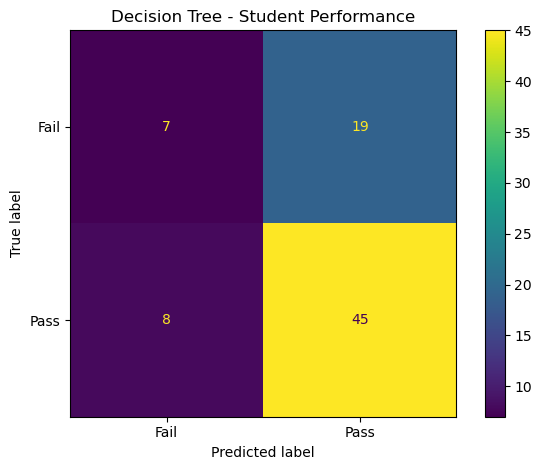

In [40]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_tree, display_labels=["Fail", "Pass"])
plt.title("Decision Tree - Student Performance")
plt.tight_layout()
plt.show()

In [41]:
from sklearn.svm import SVC
svm = Pipeline(steps=[("preprocessor", preprocessor_svm), ("model", SVC(kernel="rbf", random_state=42))])

In [42]:
svm.fit(x_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('categorical', ...), ('numerical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [43]:
y_pred_svm = svm.predict(x_test)

In [44]:
svm_accuracy = accuracy_score(y_test, y_pred_svm)
svm_precision = precision_score(y_test, y_pred_svm)
svm_recall = recall_score(y_test, y_pred_svm)
svm_f1 = f1_score(y_test, y_pred_svm)
print("SVM Results")
print("Accuracy: ", round(svm_accuracy, 4))
print("Precision: ", round(svm_precision, 4))
print("Recall: ", round(svm_recall, 4))
print("F1-score: ", round(svm_f1, 4))

SVM Results
Accuracy:  0.6835
Precision:  0.7059
Recall:  0.9057
F1-score:  0.7934


In [45]:
classification_report(y_test, y_pred_svm, target_names=["Fail", "Pass"])

'              precision    recall  f1-score   support\n\n        Fail       0.55      0.23      0.32        26\n        Pass       0.71      0.91      0.79        53\n\n    accuracy                           0.68        79\n   macro avg       0.63      0.57      0.56        79\nweighted avg       0.65      0.68      0.64        79\n'

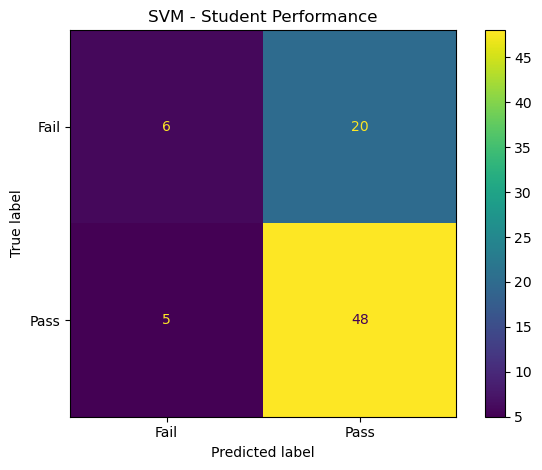

In [46]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_svm, display_labels=["Fail", "Pass"])
plt.title("SVM - Student Performance")
plt.tight_layout()
plt.show()

In [47]:
results_dataset1 = pd.DataFrame({"Model": ["Decision Tree", "SVM"], "Accuarcy": [tree_accuracy, svm_accuracy], "Precision": [tree_precision, svm_precision], "Recall": [tree_recall, svm_recall], "F1-score": [tree_f1, svm_f1]})
results_dataset1.round(4)

,Model,Accuarcy,Precision,Recall,F1-score
0,Decision Tree,0.6582,0.7031,0.8491,0.7692
1,SVM,0.6835,0.7059,0.9057,0.7934


In [48]:
feature_names = (decision_tree.named_steps["preprocessor"].get_feature_names_out())
importance = (decision_tree.named_steps["model"].feature_importances_)
feature_importance = pd.DataFrame({"Feature": feature_names, "Importance": importance}).sort_values(by="Importance", ascending=False)

In [49]:
feature_importance.head(15)

,Feature,Importance
48,numerical__failures,0.357150
55,numerical__absences,0.177092
51,numerical__goout,0.099370
27,categorical__schoolsup_no,0.056304
13,categorical__Mjob_services,0.039577
23,categorical__reason_reputation,0.037108
26,categorical__guardian_other,0.034172
18,categorical__Fjob_services,0.031890
24,categorical__guardian_father,0.030371
43,numerical__age,0.023631


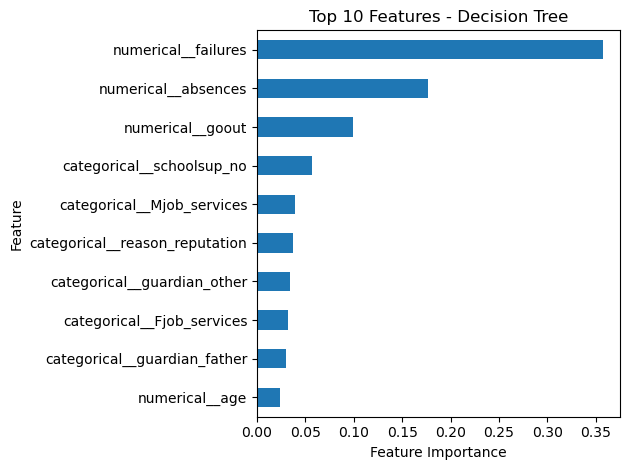

In [50]:
top_features = (feature_importance.head(10).sort_values("Importance"))
top_features.plot(x="Feature", y="Importance", kind="barh", legend=False)
plt.title("Top 10 Features - Decision Tree")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [51]:
results_dataset1.round(4).to_csv("dataset1_model_results.csv", index=False)

In [52]:
feature_importance.to_csv("dataset1_feature_importance.csv", index=False)

In [53]:
from sklearn.model_selection import StratifiedKFold, cross_validate
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
scoring_d1 = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
}
cv_dt_d1 = cross_validate(
    decision_tree,
    x,
    y,
    cv=cv,
    scoring=scoring_d1,
    n_jobs=-1
)
cv_svm_d1 = cross_validate(
    svm,
    x,
    y,
    cv=cv,
    scoring=scoring_d1,
    n_jobs=-1
)
def print_cv_results(name, results):
    print(name)
    print(f"Accuracy : {results['test_accuracy'].mean():.3f} ± {results['test_accuracy'].std():.3f}")
    print(f"Precision: {results['test_precision'].mean():.3f} ± {results['test_precision'].std():.3f}")
    print(f"Recall   : {results['test_recall'].mean():.3f} ± {results['test_recall'].std():.3f}")
    print(f"F1       : {results['test_f1'].mean():.3f} ± {results['test_f1'].std():.3f}")
    print()
print_cv_results("Dataset 1 - Decision Tree", cv_dt_d1)
print_cv_results("Dataset 1 - SVM", cv_svm_d1)

Dataset 1 - Decision Tree
Accuracy : 0.699 ± 0.044
Precision: 0.735 ± 0.033
Recall   : 0.864 ± 0.065
F1       : 0.793 ± 0.034

Dataset 1 - SVM
Accuracy : 0.719 ± 0.038
Precision: 0.721 ± 0.023
Recall   : 0.947 ± 0.025
F1       : 0.819 ± 0.024



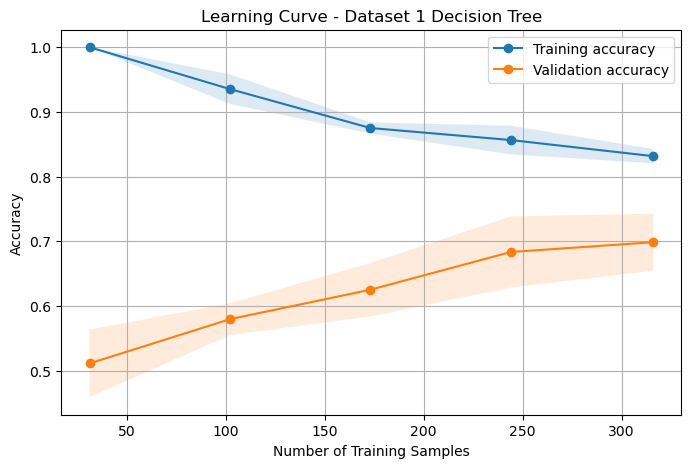

In [54]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

train_sizes, train_scores, validation_scores = learning_curve(
    decision_tree,
    x,
    y,
    cv=cv,
    scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 5),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)

validation_mean = validation_scores.mean(axis=1)
validation_std = validation_scores.std(axis=1)

plt.figure(figsize=(8, 5))

plt.plot(
    train_sizes,
    train_mean,
    marker="o",
    label="Training accuracy"
)

plt.plot(
    train_sizes,
    validation_mean,
    marker="o",
    label="Validation accuracy"
)

plt.fill_between(
    train_sizes,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.15
)

plt.fill_between(
    train_sizes,
    validation_mean - validation_std,
    validation_mean + validation_std,
    alpha=0.15
)

plt.xlabel("Number of Training Samples")
plt.ylabel("Accuracy")
plt.title("Learning Curve - Dataset 1 Decision Tree")
plt.legend()
plt.grid(True)

plt.show()

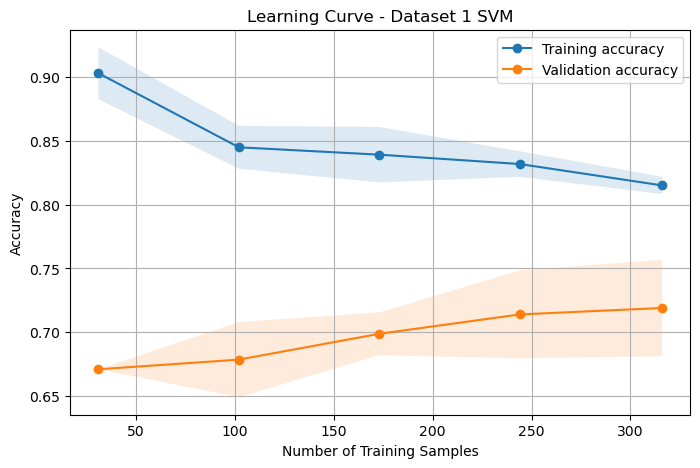

In [55]:
train_sizes, train_scores, validation_scores = learning_curve(
    svm,
    x,
    y,
    cv=cv,
    scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 5),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)

validation_mean = validation_scores.mean(axis=1)
validation_std = validation_scores.std(axis=1)

plt.figure(figsize=(8, 5))

plt.plot(
    train_sizes,
    train_mean,
    marker="o",
    label="Training accuracy"
)

plt.plot(
    train_sizes,
    validation_mean,
    marker="o",
    label="Validation accuracy"
)

plt.fill_between(
    train_sizes,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.15
)

plt.fill_between(
    train_sizes,
    validation_mean - validation_std,
    validation_mean + validation_std,
    alpha=0.15
)

plt.xlabel("Number of Training Samples")
plt.ylabel("Accuracy")
plt.title("Learning Curve - Dataset 1 SVM")
plt.legend()
plt.grid(True)

plt.show()

In [56]:
from sklearn.model_selection import learning_curve
import numpy as np

def get_learning_curve_results(model, x, y, cv):
    train_sizes, train_scores, validation_scores = learning_curve(
        model,
        x,
        y,
        cv=cv,
        scoring="accuracy",
        train_sizes=np.linspace(0.1, 1.0, 5),
        n_jobs=-1
    )

    train_mean = train_scores.mean(axis=1)
    validation_mean = validation_scores.mean(axis=1)

    return train_sizes, train_mean, validation_mean


sizes_d1_dt, train_d1_dt, val_d1_dt = get_learning_curve_results(
    decision_tree, x, y, cv
)

sizes_d1_svm, train_d1_svm, val_d1_svm = get_learning_curve_results(
    svm, x, y, cv
)


print("=" * 60)
print("DATASET 1 - DECISION TREE")
print("=" * 60)

for size, train, val in zip(sizes_d1_dt, train_d1_dt, val_d1_dt):
    print(
        f"Samples: {size:4d} | "
        f"Training: {train:.3f} | "
        f"Validation: {val:.3f} | "
        f"Gap: {train-val:.3f}"
    )

print("\nFinal gap:",
      round(train_d1_dt[-1] - val_d1_dt[-1], 3))


print("\n" + "=" * 60)
print("DATASET 1 - SVM")
print("=" * 60)

for size, train, val in zip(sizes_d1_svm, train_d1_svm, val_d1_svm):
    print(
        f"Samples: {size:4d} | "
        f"Training: {train:.3f} | "
        f"Validation: {val:.3f} | "
        f"Gap: {train-val:.3f}"
    )

print("\nFinal gap:",
      round(train_d1_svm[-1] - val_d1_svm[-1], 3))

DATASET 1 - DECISION TREE
Samples:   31 | Training: 1.000 | Validation: 0.511 | Gap: 0.489
Samples:  102 | Training: 0.935 | Validation: 0.580 | Gap: 0.356
Samples:  173 | Training: 0.875 | Validation: 0.625 | Gap: 0.250
Samples:  244 | Training: 0.857 | Validation: 0.684 | Gap: 0.173
Samples:  316 | Training: 0.832 | Validation: 0.699 | Gap: 0.133

Final gap: 0.133

DATASET 1 - SVM
Samples:   31 | Training: 0.903 | Validation: 0.671 | Gap: 0.232
Samples:  102 | Training: 0.845 | Validation: 0.678 | Gap: 0.167
Samples:  173 | Training: 0.839 | Validation: 0.699 | Gap: 0.141
Samples:  244 | Training: 0.832 | Validation: 0.714 | Gap: 0.118
Samples:  316 | Training: 0.815 | Validation: 0.719 | Gap: 0.096

Final gap: 0.096


In [58]:
!pip install fairlearn

In [59]:
import fairlearn

print("Fairlearn version:", fairlearn.__version__)

Fairlearn version: 0.14.0


In [60]:
from fairlearn.metrics import MetricFrame
from sklearn.metrics import accuracy_score
import pandas as pd
import numpy as np

# Generate predictions on the original Dataset 1 test set
dt_pred_d1 = decision_tree.predict(x_test)
svm_pred_d1 = svm.predict(x_test)

print("Dataset 1 predictions generated successfully.")

Dataset 1 predictions generated successfully.


In [61]:
sensitive_test_d1 = st1.loc[x_test.index, ["sex", "age", "address"]]

print(sensitive_test_d1.head())
print("\nTest-set shape:", sensitive_test_d1.shape)

    sex  age address
305   F   18       U
225   F   18       R
237   F   16       U
318   F   17       R
182   F   17       U

Test-set shape: (79, 3)


In [62]:
def fairness_analysis(y_true, y_pred, sensitive_data, feature_name, model_name):

    mf = MetricFrame(
        metrics={
            "accuracy": accuracy_score,
            "count": lambda y_true, y_pred: len(y_true)
        },
        y_true=y_true,
        y_pred=y_pred,
        sensitive_features=sensitive_data[feature_name]
    )

    results = mf.by_group.copy()

    print("\n" + "=" * 60)
    print(f"{model_name} - {feature_name}")
    print("=" * 60)

    print(results)

    print("\nAccuracy difference (max - min):")
    print(round(mf.difference()["accuracy"], 3))

    print("\nMinimum subgroup count:")
    print(int(results["count"].min()))

    return mf

In [63]:
dt_sex_d1 = fairness_analysis(
    y_test,
    dt_pred_d1,
    sensitive_test_d1,
    "sex",
    "Dataset 1 - Decision Tree"
)

dt_age_d1 = fairness_analysis(
    y_test,
    dt_pred_d1,
    sensitive_test_d1,
    "age",
    "Dataset 1 - Decision Tree"
)

dt_address_d1 = fairness_analysis(
    y_test,
    dt_pred_d1,
    sensitive_test_d1,
    "address",
    "Dataset 1 - Decision Tree"
)


Dataset 1 - Decision Tree - sex
     accuracy  count
sex                 
F    0.617021   47.0
M    0.718750   32.0

Accuracy difference (max - min):
0.102

Minimum subgroup count:
32

Dataset 1 - Decision Tree - age
     accuracy  count
age                 
15   0.642857   14.0
16   0.800000   20.0
17   0.590909   22.0
18   0.500000   14.0
19   0.777778    9.0

Accuracy difference (max - min):
0.3

Minimum subgroup count:
9

Dataset 1 - Decision Tree - address
         accuracy  count
address                 
R        0.769231   13.0
U        0.636364   66.0

Accuracy difference (max - min):
0.133

Minimum subgroup count:
13


In [64]:
svm_sex_d1 = fairness_analysis(
    y_test,
    svm_pred_d1,
    sensitive_test_d1,
    "sex",
    "Dataset 1 - SVM"
)

svm_age_d1 = fairness_analysis(
    y_test,
    svm_pred_d1,
    sensitive_test_d1,
    "age",
    "Dataset 1 - SVM"
)

svm_address_d1 = fairness_analysis(
    y_test,
    svm_pred_d1,
    sensitive_test_d1,
    "address",
    "Dataset 1 - SVM"
)


Dataset 1 - SVM - sex
     accuracy  count
sex                 
F    0.617021   47.0
M    0.781250   32.0

Accuracy difference (max - min):
0.164

Minimum subgroup count:
32

Dataset 1 - SVM - age
     accuracy  count
age                 
15   0.857143   14.0
16   0.800000   20.0
17   0.500000   22.0
18   0.571429   14.0
19   0.777778    9.0

Accuracy difference (max - min):
0.357

Minimum subgroup count:
9

Dataset 1 - SVM - address
         accuracy  count
address                 
R        0.615385   13.0
U        0.696970   66.0

Accuracy difference (max - min):
0.082

Minimum subgroup count:
13
